# G and GxE Analysis with LIMIX - Linear mixed model for Complex Traits

- **1.** Data loading and preprocessing
    - Phenotypic data (missing values, distributions)
    - Genotypic data (MAF, Kinship, PCA)
- **2.** Single trait analysis 
- **3.** Multi trait analysis
- **4.** Variance Decomposition for single and multi trait

In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np
from numpy.linalg import eigvals
import matplotlib.pyplot as plt
from statsmodels.sandbox.stats.multicomp import multipletests as mt

import limix_modified
from limix_modified.io.hdf5 import read_limix
from limix_modified.sh._extract import extract
from limix_modified.sh._url import download
from limix_modified.stats._kinship import linear_kinship
from limix_modified.qc._impute import mean_impute
from limix_modified.qc._quant_gauss import quantile_gaussianize
from limix_modified.qtl._scan import scan
from limix_modified.vardec._vardec import VarDec
from limix_modified.plot._manhattan import manhattan
from limix_modified.plot._qqplot import qqplot
from limix_modified.plot._kinship import kinship

# 1. Load data and preprocess

#### Yeast eQTL dataset: 109 samples with 2956 marker SNPs and 2 * 5493 expression levels, profiled in glucose and ethanol growth media

In [2]:
# Load data
url = "http://rest.s3for.me/limix/smith08.hdf5.bz2"
filepath = download(url, verbose=False)
filepath = extract(filepath, verbose=False)
data = read_limix(filepath)
print(data)

/sc/home/bibiana.horn/projects/LIMIX_modified/limix_modified/io/hdf5.py:19: UserWarning: rename 'sample_ID' to 'sample' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  Y = Y.rename(sample_ID="sample")
/sc/home/bibiana.horn/projects/LIMIX_modified/limix_modified/io/hdf5.py:28: UserWarning: rename 'sample_ID' to 'sample' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  G = G.rename(sample_ID="sample")
/sc/home/bibiana.horn/projects/LIMIX_modified/limix_modified/io/hdf5.py:35: UserWarning: rename 'sample_ID' to 'sample' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  G = G.rename(sample_ID="sample")


{'phenotype': <xarray.DataArray 'phenotype' (sample: 109, outcome: 10986)> Size: 10MB
array([[-0.03733945, -0.07816514,  0.04293578, ...,  0.09559633,
        -0.13238532, -0.27495413],
       [-0.30137615,  0.06605505,  0.33862385, ..., -0.14266055,
        -0.23834862,  0.73275229],
       [ 0.00266055,  0.12183486, -0.13706422, ..., -0.14440367,
         0.25761468,  0.01504587],
       ...,
       [-0.28733945,  0.35183486,  0.07293578, ...,  0.09733945,
        -0.03834862,  0.16275229],
       [-0.57733945,  0.01183486, -0.00706422, ...,  0.13559633,
         0.10761468,  0.24504587],
       [-0.27733945,  0.06183486,  0.13293578, ...,  0.01559633,
        -0.14238532, -0.12495413]])
Coordinates:
    sample        (sample) int64 872B 0 1 2 3 4 5 6 ... 103 104 105 106 107 108
    environment   (outcome) float64 88kB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
    gene_ID       (outcome) object 88kB 'YOL161C' 'YJR107W' ... 'YBR242W'
    gene_chrom    (outcome) object 88kB '15' '10' '16

In [3]:
G = data['genotype']
print(G)
print("Unique SNP Values in G:", np.unique(G))  # List unique values

chrom = G['chrom']  # Adjust this to the actual key in your HDF5 file
pos = G['pos'] 
pos_cum = G['pos_cum']
print(pos_cum.shape)

# Create a DataFrame
df = pd.DataFrame({
    'chrom': chrom,
    'pos': pos,
   #'pos_cum': pos_cum
})

print(df)
# Save to CSV
#df.to_csv("/sc/home/bibiana.horn/test_data/smith_data/gene_annotation_data.csv", index=False, header=True)

<xarray.DataArray 'genotype' (sample: 109, candidate: 2956)> Size: 3MB
array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])
Coordinates:
    sample   (sample) int64 872B 0 1 2 3 4 5 6 7 ... 102 103 104 105 106 107 108
    chrom    (candidate) int64 24kB 1 1 1 1 1 1 1 1 ... 16 16 16 16 16 16 16 16
    pos      (candidate) int64 24kB 483 484 3220 3223 ... 932310 932535 932538
    pos_cum  (candidate) int64 24kB 483 484 3220 ... 12055570 12055795 12055798
Dimensions without coordinates: candidate
Unique SNP Values in G: [0. 1.]
(2956,)
      chrom     pos
0         1     483
1         1     484
2         1    3220
3         1    3223
4         1    3232
...     ...     ...
2951     16  927502
2952     16  927506
2953     16  932310
2954     16  932535
2955     16  932538

[2956 rows x 2 columns]


In [4]:
pd.read_csv("/sc/home/bibiana.horn/test_data/smith_data/gene_annotation_data.csv", index_col=None, header=0)    

,chrom,pos
0,1,483
1,1,484
2,1,3220
3,1,3223
4,1,3232
...,...,...
2951,16,927502
2952,16,927506
2953,16,932310
2954,16,932535


In [5]:
Y = data['phenotype']
print('Phenotypc data', Y)
phenotype_names = Y['phenotype_ID']
print('Phenotype names', phenotype_names) 
#array(['YOL161C:0', 'YJR107W:0', 'YPL270W:0', ..., 'YJL065C:1', 'YLR118C:1', 'YBR242W:1'], dtype=object)

Phenotypc data <xarray.DataArray 'phenotype' (sample: 109, outcome: 10986)> Size: 10MB
array([[-0.03733945, -0.07816514,  0.04293578, ...,  0.09559633,
        -0.13238532, -0.27495413],
       [-0.30137615,  0.06605505,  0.33862385, ..., -0.14266055,
        -0.23834862,  0.73275229],
       [ 0.00266055,  0.12183486, -0.13706422, ..., -0.14440367,
         0.25761468,  0.01504587],
       ...,
       [-0.28733945,  0.35183486,  0.07293578, ...,  0.09733945,
        -0.03834862,  0.16275229],
       [-0.57733945,  0.01183486, -0.00706422, ...,  0.13559633,
         0.10761468,  0.24504587],
       [-0.27733945,  0.06183486,  0.13293578, ...,  0.01559633,
        -0.14238532, -0.12495413]])
Coordinates:
    sample        (sample) int64 872B 0 1 2 3 4 5 6 ... 103 104 105 106 107 108
    environment   (outcome) float64 88kB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
    gene_ID       (outcome) object 88kB 'YOL161C' 'YJR107W' ... 'YBR242W'
    gene_chrom    (outcome) object 88kB '15' '10' '1

In [6]:
# Select phenotypic data (here gene expression level) for a specific gene ID you want to analyse
#lysine_group = ["YIL094C","YDL182W","YDL131W","YER052C","YBR115C","YDR158W","YNR050C","YJR139C","YIR034C","YGL202W","YDR234W"]
gene_id = 'YJR139C' # gene of the lysine group
y = Y[:, (Y["gene_ID"] == gene_id)]  # phenotype vector (both environments)
print(y)
# Single-trait phenotype (one environment)
y_st = Y[:, (Y["gene_ID"] == gene_id) & (Y["environment"] == 1.0)]
# Print the gene_ID with the corresponding vector and shape
print(f'Phenotypic data for gene_ID {gene_id}:', y_st)
print(f'Shape of y for gene_ID {gene_id}: ', y_st.shape) # 2 columns, because the phenotype is measured for environment 0 and 1 (glucose and ethanol)

<xarray.DataArray 'phenotype' (sample: 109, outcome: 2)> Size: 2kB
array([[ 0.02733945, -0.06266055],
       [ 0.12568807, -0.03431193],
       [-0.01266055, -0.14266055],
       [ 0.11733945,  0.04733945],
       [ 0.27568807,  0.12568807],
       [ 0.07733945, -0.07431193],
       [-0.20431193, -0.15431193],
       [ 0.02568807, -0.05431193],
       [ 0.18568807,  0.21568807],
       [ 0.23733945,  0.03733945],
       [ 0.34568807,  0.14733945],
       [-0.20266055,  0.12733945],
       [ 0.36733945,  0.37568807],
       [ 0.15733945,  0.16568807],
       [-0.19431193,  0.34568807],
       [ 0.07733945, -0.00431193],
       [ 0.03733945, -0.03431193],
       [-0.26266055,  0.00733945],
       [ 0.30568807,  0.12733945],
       [ 0.21568807, -0.03266055],
...
       [ 0.13733945, -0.01266055],
       [ 0.12733945, -0.14266055],
       [-0.08431193, -0.04266055],
       [ 0.28568807,  0.07568807],
       [ 0.13733945,  0.18568807],
       [-0.02431193, -0.11431193],
       [-0.03266055

In [7]:

# Extract phenotype vector for the specific gene ID across both environments
# Extract phenotypes for environment 0 and 1 separately
y = Y[:, (Y["gene_ID"] == gene_id)]  # Replace "phenotype" with the column name for phenotypes

print(y)

# Calculate correlation
correlation = np.corrcoef(y[:, 0], y[:, 1])[0, 1]

print("Correlation between environment 0 and environment 1:", correlation)

<xarray.DataArray 'phenotype' (sample: 109, outcome: 2)> Size: 2kB
array([[ 0.02733945, -0.06266055],
       [ 0.12568807, -0.03431193],
       [-0.01266055, -0.14266055],
       [ 0.11733945,  0.04733945],
       [ 0.27568807,  0.12568807],
       [ 0.07733945, -0.07431193],
       [-0.20431193, -0.15431193],
       [ 0.02568807, -0.05431193],
       [ 0.18568807,  0.21568807],
       [ 0.23733945,  0.03733945],
       [ 0.34568807,  0.14733945],
       [-0.20266055,  0.12733945],
       [ 0.36733945,  0.37568807],
       [ 0.15733945,  0.16568807],
       [-0.19431193,  0.34568807],
       [ 0.07733945, -0.00431193],
       [ 0.03733945, -0.03431193],
       [-0.26266055,  0.00733945],
       [ 0.30568807,  0.12733945],
       [ 0.21568807, -0.03266055],
...
       [ 0.13733945, -0.01266055],
       [ 0.12733945, -0.14266055],
       [-0.08431193, -0.04266055],
       [ 0.28568807,  0.07568807],
       [ 0.13733945,  0.18568807],
       [-0.02431193, -0.11431193],
       [-0.03266055

In [8]:

#print(y.values)
# Assuming `data_array` is your xarray DataArray
#data_df = pd.DataFrame(y.values)
#print(data_df)
## Save the DataFrame as a CSV
#data_df.to_csv("/dhc/home/bibiana.horn/test_data/smith_data/phenotype_YBR115C_2_cond.csv", header=False, index=True)

#df = pd.read_csv("/dhc/home/bibiana.horn/test_data/smith_data/phenotype_YBR115C_2_cond.csv", sep= ",", header=None, index_col=0)
#print(df)
#print(df.iloc[0,0])

# Preprocess the data 

- Check the data for missing values, impute or exclude them if necessary 
- Inspect and plot the data distribution

In [9]:
# Check for missing data in each column and mean impute missing values if necessary
missing_glucose = np.isnan(y[:, 0]).sum()
missing_ethanol = np.isnan(y[:, 1]).sum()

print(f'Missing data in environment 0 (Glucose): {missing_glucose}')
print(f'Missing data in environment 1 (Ethanol): {missing_ethanol}')

# If there is missing data, handle it (e.g., by dropping rows with missing values)
if missing_glucose > 0 or missing_ethanol > 0:
    print("Handling missing data by removing rows with NaN values...")
    # Drop rows with NaN values in either column
    y_cleaned = mean_impute(y)
    print(f"Imputed missing data: {y_cleaned}")
else:
    y_cleaned = y  # No missing data, so use the original data
    print("No missing data found.")


Missing data in environment 0 (Glucose): <xarray.DataArray 'phenotype' ()> Size: 8B
array(0)
Coordinates:
    environment   float64 8B 0.0
    gene_ID       object 8B 'YJR139C'
    gene_chrom    object 8B '10'
    gene_end      int64 8B 689439
    gene_start    int64 8B 690518
    gene_strand   object 8B 'C'
    phenotype_ID  object 8B 'YJR139C:0'
Missing data in environment 1 (Ethanol): <xarray.DataArray 'phenotype' ()> Size: 8B
array(0)
Coordinates:
    environment   float64 8B 1.0
    gene_ID       object 8B 'YJR139C'
    gene_chrom    object 8B '10'
    gene_end      int64 8B 689439
    gene_start    int64 8B 690518
    gene_strand   object 8B 'C'
    phenotype_ID  object 8B 'YJR139C:1'
No missing data found.


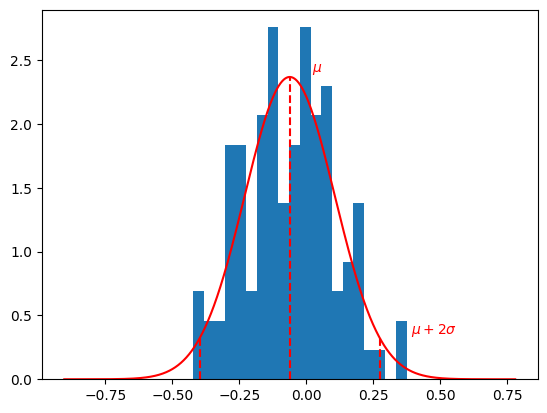

In [10]:
# Visualize your data and inspect the distribution
limix_modified.plot._normal.normal(y_st, bins=20, nstd=2, ax=None) 

# Normalize the data 

In [11]:
# Gaussianize data for better performance of the LMM
from limix_modified.qc._quant_gauss import quantile_gaussianize
y_gauss = quantile_gaussianize(y_cleaned) # two environments
y_st_gauss = quantile_gaussianize(y_st) # one environment
print(type(y_st_gauss))
print(y_st_gauss)

<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray 'phenotype' (sample: 109, outcome: 1)> Size: 872B
array([[ 0.        ],
       [ 0.10272426],
       [-0.43489814],
       [ 0.6321747 ],
       [ 1.01713143],
       [-0.0798411 ],
       [-0.49842883],
       [ 0.04559085],
       [ 1.69062163],
       [ 0.57744873],
       [ 1.18412487],
       [ 1.07624392],
       [ 2.36189445],
       [ 1.25606912],
       [ 2.0928378 ],
       [ 0.22988412],
       [ 0.10272426],
       [ 0.38532047],
       [ 1.07624392],
       [ 0.13715397],
...
       [ 0.16019525],
       [-0.43489814],
       [ 0.06841592],
       [ 0.85796989],
       [ 1.42365815],
       [-0.30070905],
       [-0.38532047],
       [ 0.        ],
       [ 0.22988412],
       [-1.18412487],
       [ 0.44745655],
       [ 0.38532047],
       [-0.38532047],
       [-0.21820072],
       [ 0.22988412],
       [-0.77834842],
       [ 0.94344263],
       [-1.33517774],
       [ 0.30070905],
       [-0.61832119]])
Coord

In [12]:
print(type(y))
import xarray as xr
import numpy as np

# Suppose y is a DataArray
y_array = y.values  # This gives you a NumPy ndarray
print(type(y_array))  # <class 'numpy.ndarray'>
y_new = quantile_gaussianize(y_array)

<class 'xarray.core.dataarray.DataArray'>
<class 'numpy.ndarray'>


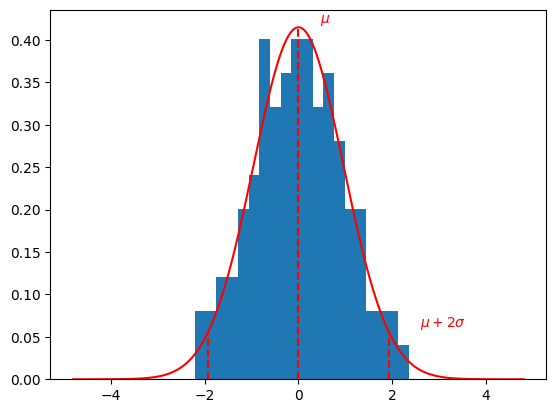

In [13]:
limix_modified.plot._normal.normal(y_st_gauss, bins=20, nstd=2, ax=None) 

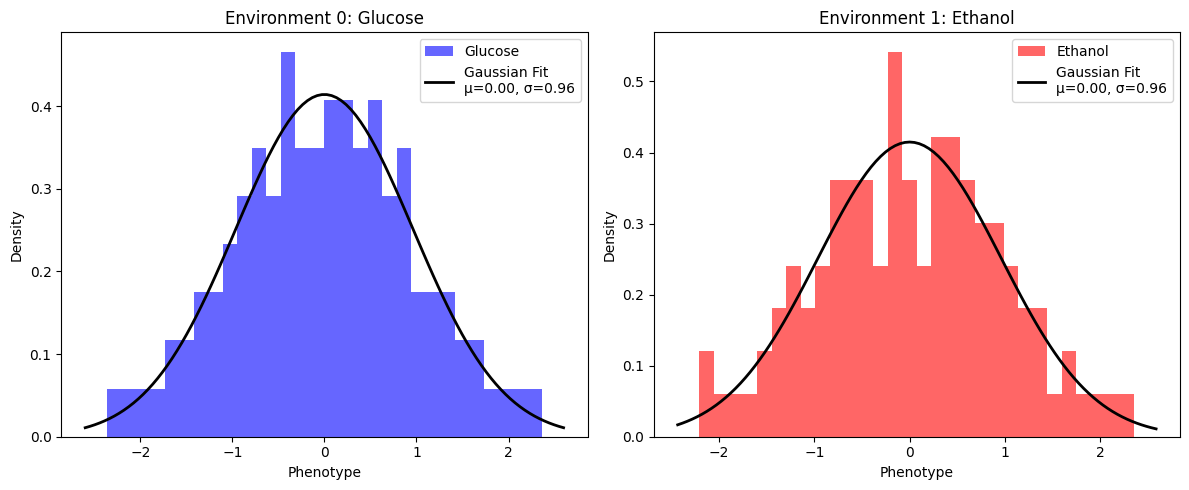

In [15]:
# Plot the distributions of y for E0 and E1
from scipy.stats import norm
# Extract phenotype data for each environment
phenotype_glucose = y_gauss[:, 0]
phenotype_ethanol = y_gauss[:, 1]

# Plotting histogram and Gaussian fit for both environments

# Define subplots for 2 environments
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Environment 0 (Glucose)
axes[0].hist(phenotype_glucose, bins=30, density=True, alpha=0.6, color='b', label='Glucose')
mu_glucose, std_glucose = norm.fit(phenotype_glucose)  # Fit a Gaussian distribution
xmin, xmax = axes[0].get_xlim()
x_glucose = np.linspace(xmin, xmax, 100)
p_glucose = norm.pdf(x_glucose, mu_glucose, std_glucose)
axes[0].plot(x_glucose, p_glucose, 'k', linewidth=2, label=f'Gaussian Fit\nµ={mu_glucose:.2f}, σ={std_glucose:.2f}')
axes[0].set_title('Environment 0: Glucose')
axes[0].set_xlabel('Phenotype')
axes[0].set_ylabel('Density')
axes[0].legend()

# Environment 1 (Ethanol)
axes[1].hist(phenotype_ethanol, bins=30, density=True, alpha=0.6, color='r', label='Ethanol')
mu_ethanol, std_ethanol = norm.fit(phenotype_ethanol)  # Fit a Gaussian distribution
xmin, xmax = axes[1].get_xlim()
x_ethanol = np.linspace(xmin, xmax, 100)
p_ethanol = norm.pdf(x_ethanol, mu_ethanol, std_ethanol)
axes[1].plot(x_ethanol, p_ethanol, 'k', linewidth=2, label=f'Gaussian Fit\nµ={mu_ethanol:.2f}, σ={std_ethanol:.2f}')
axes[1].set_title('Environment 1: Ethanol')
axes[1].set_xlabel('Phenotype')
axes[1].set_ylabel('Density')
axes[1].legend()

# Show the plots
plt.tight_layout()
plt.show()

In [16]:
# Check pairwise distributions

Y = data['phenotype']

# We focus on a subset of 11 genes in the Lysine Biosynthesis KEEG pathway
lysine_group = ["YIL094C","YDL182W","YDL131W","YER052C","YBR115C","YDR158W","YNR050C","YJR139C","YIR034C","YGL202W","YDR234W"]

gaussianized_df = pd.DataFrame()

for i, gene in enumerate(lysine_group):
    print(f"Running QTL analysis for gene: {gene}")
    
    # Extract y_st based on gene ID and environment
    y_st = Y[:, (Y["gene_ID"] == gene) & (Y["environment"] == 0.0)]
    y_st_gaussianized = quantile_gaussianize(y_st)

    gene_df = pd.DataFrame(y_st_gaussianized, columns=[gene])
    gaussianized_df = pd.concat([gaussianized_df, gene_df], axis=1)


print(gaussianized_df)

Running QTL analysis for gene: YIL094C
Running QTL analysis for gene: YDL182W
Running QTL analysis for gene: YDL131W
Running QTL analysis for gene: YER052C
Running QTL analysis for gene: YBR115C
Running QTL analysis for gene: YDR158W
Running QTL analysis for gene: YNR050C
Running QTL analysis for gene: YJR139C
Running QTL analysis for gene: YIR034C
Running QTL analysis for gene: YGL202W
Running QTL analysis for gene: YDR234W
      YIL094C   YDL182W   YDL131W   YER052C   YBR115C   YDR158W   YNR050C  \
0   -0.660254  0.102724 -0.646151  0.068416  1.281552 -0.434898  0.253347   
1    0.171747 -0.276950  0.373077 -0.447457  0.472789 -0.747859  0.688864   
2   -1.794538 -0.091277 -1.644854 -1.335178  1.184125 -1.096804 -1.524945   
3   -0.068416 -0.841621 -0.324639  0.943443 -0.472789  1.139378 -0.809580   
4    0.550731  1.096804 -0.809580 -1.184125  0.206547 -2.092838  1.524945   
..        ...       ...       ...       ...       ...       ...       ...   
104 -1.335178 -0.422408 -2.36189

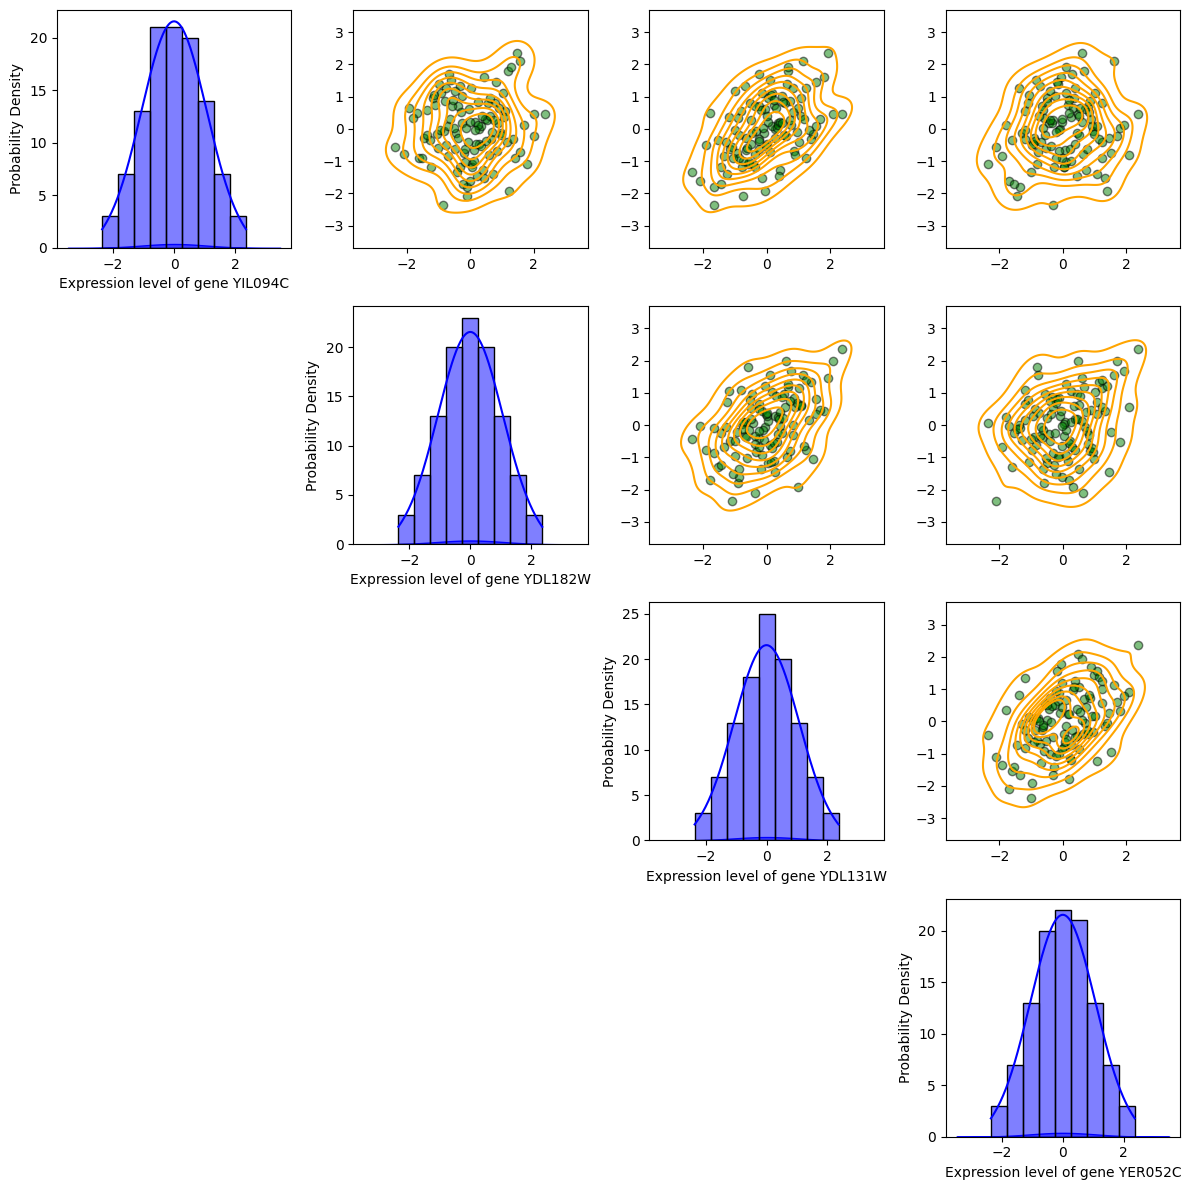

In [ ]:
# Visualizing Pairwise Distributions of Selected Traits
from limix_modified.plot._pairwise_correlation import pairwise_distributions
df_subset = gaussianized_df.iloc[:, :4]
# Merge each column label with the string "Expression level of gene"
merged_labels = [f"Expression level of gene {label}" for label in df_subset.columns.tolist()]
pairwise_distributions(df_subset, 
                       column_labels=merged_labels,
                       hist_color="blue",
                       hist_fill="blue",
                       label_size=10,
                       scatter_color="green",
                       kde_color="orange",
                       kde_fill=False,
                       scatter_alpha=0.5,
                       figsize=(12, 12)
                       )

## Extract the genotype matrix G

In [ ]:
G = data['genotype']
print('Genotype data', G)
print('Type of genotype data:', type(G))
print("Shape of genotype data: ", G.shape)

data_df = pd.DataFrame(G.values)
#data_df.to_csv("/sc/home/bibiana.horn/test_data/smith_data/genotype_yeast.csv", header=False, index=True)


#df = pd.read_csv("/dhc/home/bibiana.horn/test_data/smith_data/G_all_genotype.csv", sep= ",", header=None, index_col=0)
#print(df)

Genotype data <xarray.DataArray 'genotype' (sample: 109, candidate: 2956)> Size: 3MB
array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])
Coordinates:
    sample   (sample) int64 872B 0 1 2 3 4 5 6 7 ... 102 103 104 105 106 107 108
    chrom    (candidate) int64 24kB 1 1 1 1 1 1 1 1 ... 16 16 16 16 16 16 16 16
    pos      (candidate) int64 24kB 483 484 3220 3223 ... 932310 932535 932538
    pos_cum  (candidate) int64 24kB 483 484 3220 ... 12055570 12055795 12055798
Dimensions without coordinates: candidate
Type of genotype data: <class 'xarray.core.dataarray.DataArray'>
Shape of genotype data:  (109, 2956)


# Minor Allele Frequency (MAF) 

##### MAF is the proportion of the minor allele (the less common variant) relative to the total number of alleles at that locus

The Minor Allele Frequency (MAF) is calculated using the formula:

$$
\text{MAF} = \frac{\text{count of minor allele}}{\text{count of total alleles}}
$$

Where:
- A value of **0** indicates that an individual is homozygous for the reference allele.
- A value of **1** indicates that an individual is heterozygous (one reference allele and one minor allele).
- A value of **2** indicates that an individual is homozygous for the minor allele.

SNPs with low MAF (e.g., <0.05 or <0.1) might be less informative in GWAS, as they can lead to lower statistical power. This is because rare alleles are often less represented in the population, making it more difficult to detect significant associations.

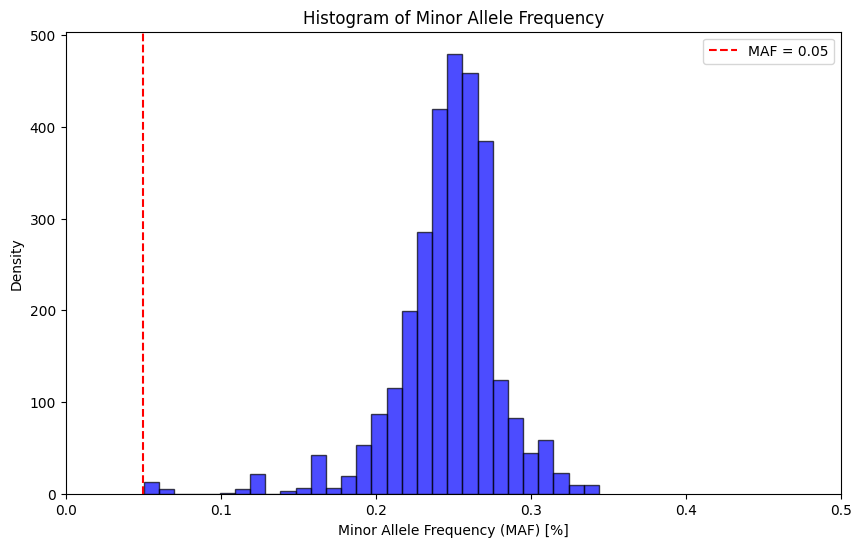

In [ ]:
from limix_modified.qc._allele import compute_maf
maf=compute_maf(G.values)

# Prepare for plotting the histogram of MAF
plt.figure(figsize=(10, 6))
plt.hist(maf, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Minor Allele Frequency')
plt.xlabel('Minor Allele Frequency (MAF) [%]')
plt.ylabel('Density')
plt.xlim(0, 0.5)  # MAF can range from 0 to 1
plt.axvline(x=0.05, color='r', linestyle='--', label='MAF = 0.05') 
plt.legend()
plt.show()

# Capture the genetic relatedness by calculating the Kinship matrix K

In machine learning and statistics, a **kernel function** computes the similarity between pairs of data points. A **linear kernel** is the simplest type, where the similarity between two vectors $X_i$ and $X_j$ is given by their dot product: 

$$ 
X_i \cdot X_j 
$$

When applied to genotype data, the linear kernel involves computing the dot product of standardized genotype vectors to estimate their genetic relatedness.

Let $d$ be the number of columns of the matrix $G$. The resulting matrix is given by:

$$
K = \frac{XX^T}{d}
$$

where 

$$
X_{ij} = \frac{G_{ij} - m_j}{s_j}
$$

is the matrix $G$ column-wise normalized by means $m_j$ and standard deviations $s_j$. NaNs are ignored to ensure that the resulting matrix $K$ contains only real numbers.

Kinship:   0%|          | 0/101 [00:00<?, ?it/s]

Kinship: 100%|██████████| 101/101 [00:00<00:00, 692.48it/s]


<class 'numpy.ndarray'>


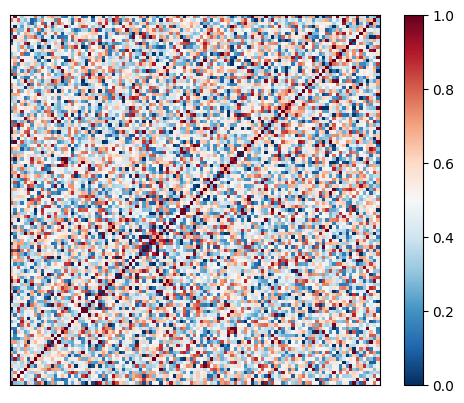

In [ ]:
# Compute and plot the kinship matrix
K = linear_kinship(G)
#print('Kinship matrix:', K)
print(type(K))
kinship(K) # the function kinship is plotting the matrix K

# Standardize G 

In [ ]:
# Z-score Normalization/ standardization
G_norm = (G - np.mean(G, axis=0)) / np.std(G, axis=0)

print('Normalized Genotype Data:')
print(G_norm)
print('Type of normalized genotype data:', type(G_norm))
print("Shape of normalized genotype data: ", G_norm.shape)

Normalized Genotype Data:
<xarray.DataArray 'genotype' (sample: 109, candidate: 2956)> Size: 3MB
array([[ 1.08627805,  1.12731244,  1.04697366, ..., -0.95513387,
        -1.06642154, -1.06642154],
       [ 1.08627805, -0.88706553,  1.04697366, ...,  1.04697366,
         0.93771549,  0.93771549],
       [-0.92057462, -0.88706553, -0.95513387, ..., -0.95513387,
        -1.06642154, -1.06642154],
       ...,
       [-0.92057462, -0.88706553, -0.95513387, ..., -0.95513387,
         0.93771549,  0.93771549],
       [-0.92057462, -0.88706553, -0.95513387, ...,  1.04697366,
         0.93771549,  0.93771549],
       [ 1.08627805,  1.12731244,  1.04697366, ...,  1.04697366,
         0.93771549,  0.93771549]])
Coordinates:
    sample   (sample) int64 872B 0 1 2 3 4 5 6 7 ... 102 103 104 105 106 107 108
    chrom    (candidate) int64 24kB 1 1 1 1 1 1 1 1 ... 16 16 16 16 16 16 16 16
    pos      (candidate) int64 24kB 483 484 3220 3223 ... 932310 932535 932538
    pos_cum  (candidate) int64 24kB 4

# Principal Component Analysis (PCA)

- PCA is a statistical technique used to simplify the complexity of high-dimensional data while preserving as much variance as possible

- The resulting principal components (PCs) are the eigenvectors of the matrix, ordered by the amount of variance they explain in the genotype data 

In [ ]:
from sklearn.decomposition import PCA
# Assuming `genotype_matrix` is your genotype data
G_new=G_norm
pca = PCA(n_components=5)  # For example, first 2 PCs
pcs = pca.fit_transform(G_new)
# Display the principal components
print("Principal Components:\n", pcs) # projections of the original samples onto the first and second principal component



Principal Components:
 [[-1.57434589e+01 -1.31619459e+01  7.42971324e-01  1.18537558e+01
   1.87170823e+01]
 [ 1.89720298e+01 -4.65145564e+00  1.19565068e+01  1.03763955e+01
  -9.68447842e+00]
 [-6.05582448e+00  1.31974128e+01 -5.01883860e+00  9.85640132e+00
  -8.46023123e+00]
 [ 1.09823079e+01 -8.69744899e+00  1.73652578e+00  9.54500085e+00
  -1.38820548e+01]
 [ 8.65629771e+00  1.12242564e+00 -2.28485567e+00 -1.55765103e+01
   1.14378637e+01]
 [ 1.25617653e+01  3.34023296e+00 -2.18832257e+01 -1.14173780e+01
   8.39440700e+00]
 [-3.99575787e+00  8.46636836e+00  1.64454547e+01  5.65876165e+00
  -3.00656805e-01]
 [ 1.25106525e+01 -2.45270049e+00  7.73568294e+00  1.01752473e+01
  -1.84609961e+00]
 [-9.63620061e+00  1.62386124e+01  1.02489497e+00  8.25104643e+00
   1.52642976e+01]
 [-1.69686166e+01 -2.87300571e+00 -1.11519117e+01 -8.85100748e-01
  -6.69727395e+00]
 [ 8.10296379e+00  1.11774756e+01 -4.08685876e+00 -1.11969038e+01
   2.89754302e+00]
 [ 1.07139251e+01  1.84958551e+01  2.13461

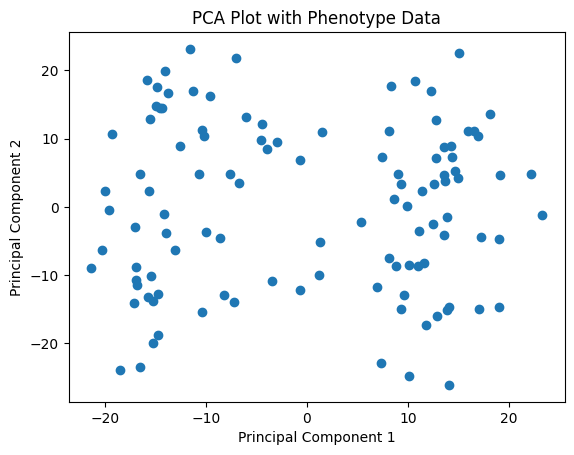

In [ ]:
# Plot the first two Principal Components
plt.scatter(pcs[:, 0], pcs[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Plot with Phenotype Data')
plt.show()

# 2. Single Trait Analysis

The model to understand the relationship between a phenotype and covariates, including genetic information from a specific SNP, is specified as follows:

$$
y = \text{M} \alpha + x \beta + g + \Psi, \quad g \sim \mathcal{N}(0, \sigma_g^2K), \, \Psi \sim \mathcal{N}(0, \sigma_e^2I_N))
$$
where:

- $ y $ = phenotype vector $\in \mathbb{R}^{N,1}$
- $ M $ = matrix of covariates K $\in \mathbb{R}^{N,K}$
- $ \alpha $ = effect size of covariates $\in \mathbb{R}^{K, 1}$
- $ x $ = genetic profile of the SNP being tested $\in \mathbb{R}^{N, 1}$ 
- $ \beta $ = effect size of the SNP $\in \mathbb{R}$
- $ g $ = genetic effect due to relatedness between individuals
- $ K $ = sample relatedness matrix $\in \mathbb{R}^{N, N}$ 
- $ \Psi $ = residual error

### Distribution of Phenotype

The overall distribution of the phenotype can be represented as:
$$
y \sim \mathcal{N}(M\alpha + x\beta, \sigma_g^2 K + \sigma_e^2 I_n)
$$

The phenotype $y$ follows a normal distribution with a mean defined by the linear combination of fixed effects (from covariates and SNP) and a covariance structure that accounts for both genetic relatedness and error variance.


# Hypothesis testing for a single-trait

- **H0**: Tested SNP has no effect on gene expression level -> effect size 𝛃 = 0
- **H1**: Tested SNP has an effect on gene expression level -> effect size 𝛃 ≠ 0

### Likelihood Ratio Test (LRT) Calculation

In the context of the Likelihood Ratio Test (LRT), we can calculate the test statistic and the p-value as follows:

1. **Calculate the LRT Statistic**:

   The LRT statistic $\lambda$ is computed using the log-likelihoods of the null and alternative models:
   $$
   \text{LRT} = -2 \cdot \log\left( \frac{\mathcal{L}(\hat{\theta}_0; X_1, \ldots, X_n)}{\mathcal{L}(\hat{\theta}; X_1, \ldots, X_n)} \right)
   $$
   Where:
   - $ \mathcal{L}(\hat{\theta}_0; X_1, \ldots, X_n) $ is the likelihood of the null model (where $ \beta = 0 $)
   - $ \mathcal{L}(\hat{\theta}; X_1, \ldots, X_n) $ is the likelihood of the alternative model (where $ \beta \neq 0 $)

2. **Calculate the p-value**:

   The p-value can be determined using the Chi-square distribution:
   $$
   p = 1 - \chi^2(\text{LRT}, df)
   $$
   Where:
   - $df$ is the degrees of freedom, which is typically equal to the difference in the number of parameters between the alternative and null models.



In [ ]:
# Run Analysis
num_samples = y.shape[0]
print(num_samples)

# You could also take specific covariates into account (e.g. age, sex)
# or choose PCs as additional covariates (can improve statistical power (not always) -> check with QQ Plot)
#M = pcs # or None 

qtl_st = scan(G=G_norm, Y=y_st_gauss, lik='normal', K=K, M=None, verbose=True) # lik: Sample likelihood describing the residual distribution
print(qtl_st)

109


================================= QTL analysis starts ==================================

Normalising input... 
done (0.03 seconds).

Input
-----

Likelihood       : normal
Traits (1)       : [0]
Covariates (1)   : ['offset']
Variants 2956    : [0, 1, 2, ..., 2955]
N. of candidates : 2956
Kinship          : present



LMM: 22it [00:00, 385.76it/s]
Results: 100%|██████████| 2956/2956 [00:00<00:00, 33183.80it/s]



Hypothesis 0
------------

𝐲 ~ 𝓝(𝙼𝜶, 0.535⋅𝙺 + 0.446⋅𝙸)

M     = ['offset']
𝜶     = [0.0003916]
se(𝜶) = [0.06396318]
lml   = -145.6287910146407

Hypothesis 2
------------

𝐲 ~ 𝓝(𝙼𝜶 + G𝛃, s(0.535⋅𝙺 + 0.446⋅𝙸))

          lml       cov. effsizes   cand. effsizes
--------------------------------------------------
mean   -1.452e+02       3.916e-04       -7.480e-03
std     9.125e-01       0.000e+00        1.033e-01
min    -1.456e+02       3.916e-04       -4.675e-01
25%    -1.456e+02       3.916e-04       -6.766e-02
50%    -1.454e+02       3.916e-04        1.057e-02
75%    -1.451e+02       3.916e-04        6.669e-02
max    -1.312e+02       3.916e-04        3.229e-01

Likelihood-ratio test p-values
------------------------------

       𝓗₀ vs 𝓗₂ 
----------------
mean   5.283e-01
std    2.820e-01
min    7.702e-08
25%    3.009e-01
50%    5.496e-01
75%    7.626e-01
max    9.996e-01


========================== QTL analysis ends in 0.49 seconds ===========================

Hypothesis 0
------------

𝐲 ~ 𝓝(𝙼𝜶, 0.535⋅𝙺 + 0.446⋅𝙸)

M     = ['offset']
𝜶     = [0.0003916]
se(𝜶) = [0.06396318]
lml   = -145.6287910146407

Hypothesis 2
------------

𝐲 ~ 𝓝(𝙼𝜶 + G𝛃, s(0.535⋅𝙺 + 0.446⋅𝙸))

          lml       cov. effsizes   cand. effsizes
--------------------------------------------------
mean   -1.452e+02       3.916e-04       -7.480e-03
std     9.125e-01       0.000e+00        1.033e-01
min    -1.456e+02       3.916e-04       -4.675e-01
25%    -1.456e+02       3.916e-04       -6.766e-02
50%    -1.454e+02       3.916e-04        1.057e-02
75%    -1.451e+02       3.916e-04        6.669e-02
max    -1.312e+02       3.916e-04        3.229e-01

Likelihood-ratio test p-values
------------------------------

       𝓗₀ vs 𝓗₂ 
----------------
mean   5.283e-01
std    2.820e-01
min    7.702e-08
25%    3.009e-01
50%    5.496e-01
75%    7.626e-01
max    9.996e-01


In [ ]:
qtl_st.stats
sorted_df = qtl_st.stats.sort_values(by='pv20', ascending=True)

# If you want to see the sorted DataFrame
print(sorted_df)

            lml0        lml2  dof20    scale2          pv20
test                                                       
2490 -145.628791 -131.189010      1  0.767244  7.702133e-08
2491 -145.628791 -131.359494      1  0.769648  9.184930e-08
2492 -145.628791 -132.718344      1  0.789079  3.746113e-07
2493 -145.628791 -132.718344      1  0.789079  3.746113e-07
2494 -145.628791 -136.758673      1  0.849800  2.532137e-05
...          ...         ...    ...       ...           ...
2280 -145.628791 -145.628787      1  1.000000  9.976424e-01
1622 -145.628791 -145.628788      1  1.000000  9.979245e-01
2539 -145.628791 -145.628788      1  1.000000  9.979740e-01
203  -145.628791 -145.628790      1  1.000000  9.990087e-01
2458 -145.628791 -145.628791      1  1.000000  9.996339e-01

[2956 rows x 5 columns]


## Manhatten Plot

- Displays the significance of association results between genetic variants and phenotypes
- The significance level must be corrected for multiple testing in hypothesis testing. Otherwise, the probability of incorrectly rejecting at least one null hypothesis (false positive) increases, leading to a higher Type I error rate. The adjusted significance level can be calculated using the Bonferroni method:

$$ 
\alpha_{\text{adjusted}} = \frac{\alpha}{m} 
$$

where $ \alpha $ is the desired significance level (commonly set at 0.05) and $ m $ is the total number of tests conducted.

      chrom     pos        pv
0         1     483  0.419848
1         1     484  0.970389
2         1    3220  0.284764
3         1    3223  0.284764
4         1    3232  0.284764
...     ...     ...       ...
2951     16  927502  0.199239
2952     16  927506  0.199239
2953     16  932310  0.623607
2954     16  932535  0.645459
2955     16  932538  0.645459

[2956 rows x 3 columns]
      chrom     pos            pv
2490     14  449639  7.702133e-08
2491     14  486861  9.184930e-08
2492     14  502316  3.746113e-07
2493     14  502496  3.746113e-07
2494     14  525061  2.532137e-05
...     ...     ...           ...
2280     13  216028  9.976424e-01
1622     10  535311  9.979245e-01
2539     15    1212  9.979740e-01
203       2  199107  9.990087e-01
2458     14  191243  9.996339e-01

[2956 rows x 3 columns]


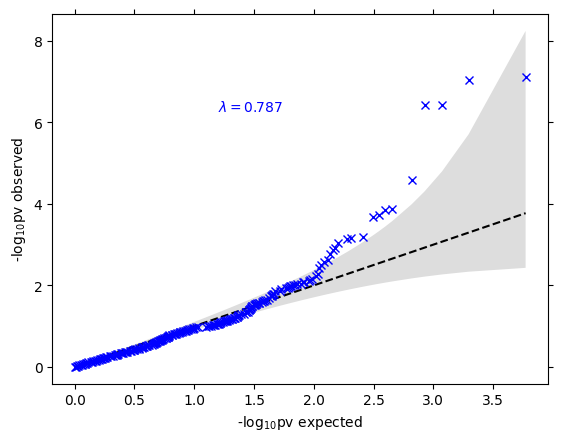

In [ ]:
stats_st = qtl_st.stats

chromosomes = G['chrom']  # Adjust this to the actual key in your HDF5 file
positions = G['pos'] 

result_st = DataFrame({
    'chrom': chromosomes,
    'pos': positions,
    'pv': stats_st['pv20'].values #pv10, pv20, pv21, ...: These columns represent the p-values associated with different tests. The number after "pv" corresponds to the comparison between different models. For example, "pv10" represents the p-value associated with the comparison between model 1 (genetic effect only) and model 0 (null model). Similarly, "pv20" represents the p-value associated with the comparison between model 2 (environmental effect only) and the null model.
})
print(result_st)
sorted_df = result_st.sort_values(by='pv', ascending=True)
print(sorted_df)
#Correct the alpha level for multiple tests
reject_, pvals_corrected_, alphacSidak, alphacBonf = mt(stats_st['pv20'].values, alpha=0.05, method='bonferroni')


#manhattan(result_st, colora="#5689AC", colorb="#21334F", highlight_color="#FFA500", threshold=alphacBonf, pts_kws=None, ax=None)
qqplot(stats_st['pv20'].values, line='s', label='Without PCs', alpha=alphacBonf, pts_kws=dict(marker='x', color='blue'))

# Manhattan Plot for All Lysine Pathway Genes

In [ ]:
# Define your lysine_group of genes
lysine_group = ["YIL094C", "YDL182W", "YDL131W", "YER052C", 
                "YBR115C", "YDR158W", "YNR050C", "YJR139C", 
                "YIR034C", "YGL202W", "YDR234W"]

all_results = pd.DataFrame()

for i, gene in enumerate(lysine_group):
    print(f"Running analysis for expression level of gene: {gene}")
    
    # Extract y_st based on gene ID and environment
    y_st = Y[:, (Y["gene_ID"] == gene) & (Y["environment"] == 1.0)]
    y_st = quantile_gaussianize(y_st)
    
    # Perform QTL analysis for the current gene
    qtl_st = scan(G=G_norm, Y=y_st, lik='normal', K=K, M=pcs, verbose=False)
    
    # Extract the statistics
    stats_st = qtl_st.stats
    
    # Prepare results for the current gene
    result_st = pd.DataFrame({
        'chrom': G['chrom'].values,  # Chromosome information
        'pos': G['pos'].values,      # Position information
         #'pv': stats_st['pv20'].values,    # p-values for the QTL
        #'gene': gene                       # Store the gene name
    })

    gene_df = pd.DataFrame(stats_st['pv20'].values, columns=[gene])

    if i==0:
        all_results = pd.concat([all_results, result_st], axis=1)
        all_results = pd.concat([all_results, gene_df], axis=1)
    else:
        all_results = pd.concat([all_results, gene_df], axis=1)


Running analysis for expression level of gene: YIL094C
Running analysis for expression level of gene: YDL182W
Running analysis for expression level of gene: YDL131W
Running analysis for expression level of gene: YER052C
Running analysis for expression level of gene: YBR115C
Running analysis for expression level of gene: YDR158W
Running analysis for expression level of gene: YNR050C
Running analysis for expression level of gene: YJR139C
Running analysis for expression level of gene: YIR034C
Running analysis for expression level of gene: YGL202W
Running analysis for expression level of gene: YDR234W


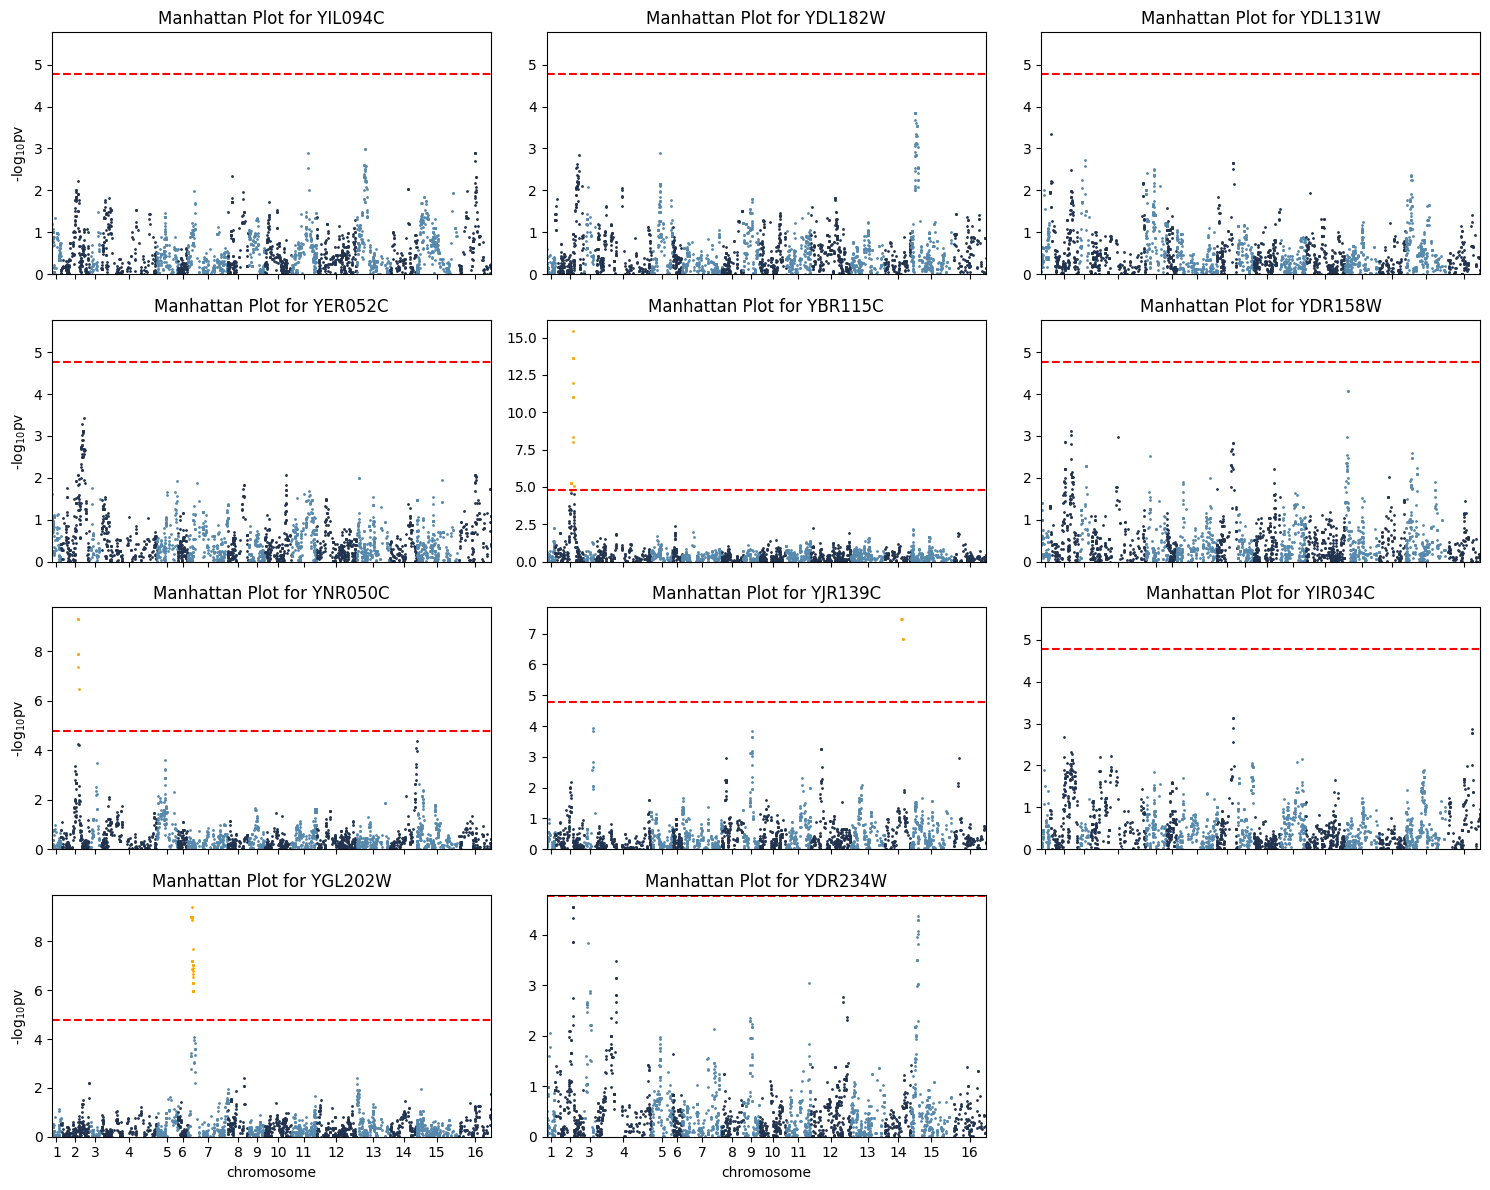

In [ ]:
# Manhatten plots of all genes in the lysine group
num_genes = len(lysine_group)

# Calculate the number of rows needed (2 columns)
num_cols = 3
num_rows = int(np.ceil(num_genes / num_cols))  # Round up to ensure enough rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3), sharex=True)
axes = axes.flatten()

# Iterate through each gene and create a Manhattan plot
for i, gene in enumerate(lysine_group):
    # Create a new DataFrame for the current gene
    gene_data = all_results[['chrom', 'pos', gene]].rename(columns={gene: 'pv'})
    
    # Create the Manhattan plot for the current gene
    manhattan(gene_data,  threshold=alphacBonf, ax=axes[i])
    axes[i].set_title(f'Manhattan Plot for {gene}')

    # Remove redundant x and y labels
    if i % num_cols != 0:  # Remove y-labels for all but the first column
        axes[i].set_ylabel('')  
    if i < (num_rows - 1) * num_cols:  # Remove x-labels for all but the last row
        axes[i].set_xlabel('')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
all_results_wo_pcs = pd.DataFrame()

for i, gene in enumerate(lysine_group):
    print(f"Running analysis without PCs for expression level of gene: {gene}")
    
    # Extract y_st based on gene ID and environment
    y_st = Y[:, (Y["gene_ID"] == gene) & (Y["environment"] == 0.0)]
    y_st = quantile_gaussianize(y_st)
    
    # Perform analysis for the current gene without PCs
    qtl_st_wo_pcs = scan(G=G_norm, Y=y_st, lik='normal', K=K, M=None, verbose=False)
    # Extract the statistics
    stats_st_wo_pcs = qtl_st_wo_pcs.stats
    
    # Prepare results for the current gene
    result_st_wo_pcs = pd.DataFrame({
        'chrom': G['chrom'].values,  # Chromosome information
        'pos': G['pos'].values,      # Position information
    })

    gene_df = pd.DataFrame(stats_st_wo_pcs['pv20'].values, columns=[gene])
    # Append the results to the all_results DataFrame
    if i==0:
        all_results_wo_pcs = pd.concat([all_results_wo_pcs, result_st_wo_pcs], axis=1)
        all_results_wo_pcs = pd.concat([all_results_wo_pcs, gene_df], axis=1)
    else:
        all_results_wo_pcs = pd.concat([all_results_wo_pcs, gene_df], axis=1)

#print(all_results_wo_pcs)        

Running analysis without PCs for expression level of gene: YIL094C
Running analysis without PCs for expression level of gene: YDL182W
Running analysis without PCs for expression level of gene: YDL131W
Running analysis without PCs for expression level of gene: YER052C
Running analysis without PCs for expression level of gene: YBR115C
Running analysis without PCs for expression level of gene: YDR158W
Running analysis without PCs for expression level of gene: YNR050C
Running analysis without PCs for expression level of gene: YJR139C
Running analysis without PCs for expression level of gene: YIR034C
Running analysis without PCs for expression level of gene: YGL202W
Running analysis without PCs for expression level of gene: YDR234W


# Quantile-Quantile (QQ) plot 

- commonly used to assess the quality and reliability of GWAS results by comparing the expected distribution of test statistics under the H0 to the observed distribution

### Genomic Control (GC) in GWAS

The **lambda (λ)** statistic is used to assess the inflation of p-values in Genome-Wide Association Studies (GWAS). It is calculated as:

$$
\lambda_{GC} = \frac{\text{Median}(\chi^2_{\text{observed}})}{\text{Median}(\chi^2_{\text{expected}})}
$$

where:
- $\chi^2_{\text{observed}}$ represents the observed chi-squared statistics derived from the p-values of your genetic association results.
- $\chi^2_{\text{expected}}$ represents the expected chi-squared statistics under the null hypothesis.


#### Interpretation:
- $\lambda = 1$: No inflation; p-values follow the expected distribution.
- $\lambda > 1$: Indicates inflation, suggesting potential biases or confounding factors. It indicates an excess of significant findings.
- $\lambda < 1$: This might suggest conservative testing or a lower rate of significant findings than anticipated.

The lambda statistic is crucial for diagnosing potential biases in GWAS analyses and making necessary adjustments.

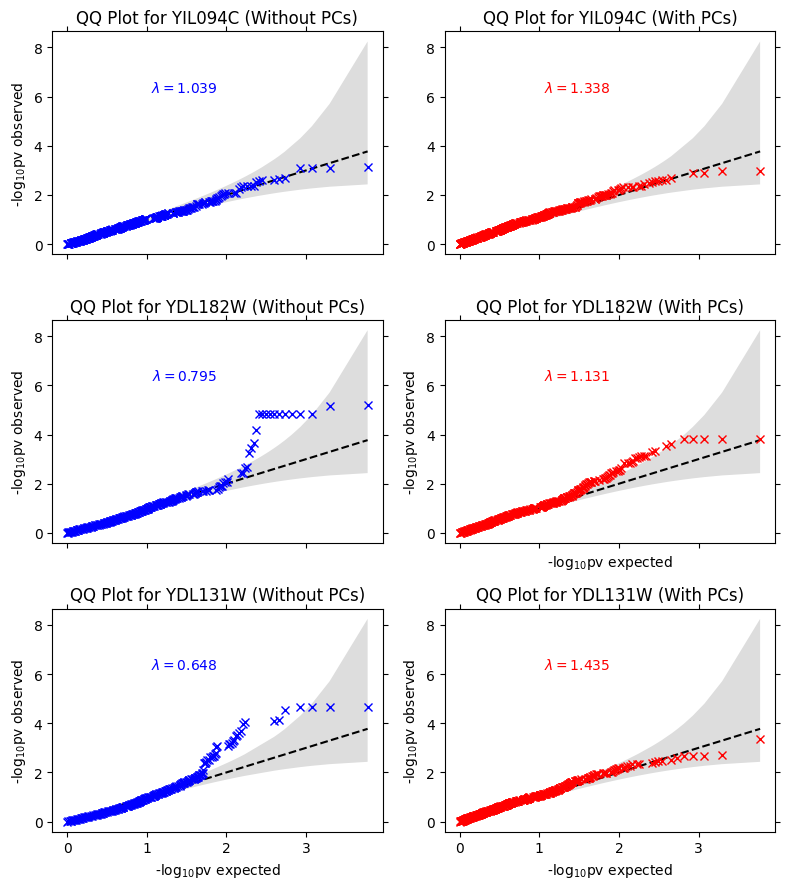

In [ ]:
# QQ Plot - Comparison of fit with and without PCs

num_genes = len(lysine_group[:3])

# Set up the number of columns and rows
num_cols = 2
num_rows = int(np.ceil(num_genes))  # Round up to ensure enough rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, num_rows * 3), sharex=True)
axes = axes.flatten()

for i, gene in enumerate(lysine_group[:3]):
    gene_data = all_results[['chrom', 'pos', gene]].rename(columns={gene: 'pv'})
    pv = gene_data['pv']
    gene_data_wo_pcs = all_results_wo_pcs[['chrom', 'pos', gene]].rename(columns={gene: 'pv'})
    pv_wo_pcs = gene_data_wo_pcs['pv']

    # Plot the QQ plots side by side
    qqplot(pv_wo_pcs, line='s', ax=axes[2*i], label='Without PCs', alpha=alphacBonf, pts_kws=dict(marker='x', color='blue'))
    qqplot(pv, line='s', ax=axes[2*i + 1], label='With PCs', alpha=alphacBonf, pts_kws=dict(marker='x', color='red'))

    # Set titles for each subplot
    axes[2*i].set_title(f'QQ Plot for {gene} (Without PCs)')
    axes[2*i + 1].set_title(f'QQ Plot for {gene} (With PCs)')

    # Remove redundant x and y labels
    if i % num_cols != 0:  # Remove y-labels for all but the first column
        axes[i].set_ylabel('')  
    if i < (num_rows - 1) * num_cols:  # Remove x-labels for all but the last row
        axes[i].set_xlabel('')

# Remove any unused subplots if num_genes is odd
for j in range(2 * num_genes, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

# 3. Multi-Trait Linear Mixed Model (LMM)

- MT Models consider an across-trait axis of variation
  - Fixed effects require a sample design denoted by A
  - Random effects additionally require a sample covariance matrix denoted by C (different to single trait)
- The general multi-trait linear mixed models can be written as:


$$
\mathbf{Y}=\mathbf{MWA}^\text{(cov)}+\mathbf{XBA}^\text{(snp)}+\mathbf{G}+\boldsymbol{\Psi},\;\;\;\;\;
\mathbf{G}\sim\text{MVN}(\mathbf{0},\mathbf{K},\mathbf{C}_g),\;
\boldsymbol{\Psi}\sim\text{MVN}(\mathbf{0},\mathbf{I}_N,\mathbf{C}_n),
$$

- **Where**: 
  - $Y$   = matrix-variate phenotype $ \in \mathcal{R}^{N,P} $
  - $M$   = sample design for covariates $ \in \mathcal{R}^{N,K} $
  - $W$   = effect size matrix for covariates $ \in \mathcal{R}^{K,L} $
  - $A^\text{(cov)}$ = trait design for the fixed effect $\in \mathcal{R}^{L,P} $
  - $B$   = effect sizes of the SNP $\in \mathcal{R}^{1,M} $
  - $X$   = genetic profile of the SNP $\in \mathcal{R}^{N,1} $
  - $A^\text{(snp)}$ = trait design for the fixed effect $\in \mathcal{R}^{M,P} $
  - $K $  = sample relatedeness matrix $\in \mathcal{R}^{N,N}$ 
  - $C_g$ = genetic trait covariance matrix $\in \mathcal{R}^{P,P} $
  - $I_N$ = sample noise matrix $ \in \mathcal{R}^{N,N} $
  - $C_n$ = noise trait covariance matrix $ \in \mathcal{R}^{P,P} $
  - $n$: Number of samples  
  - $p$: Number of traits (e.g., gene expression levels, ERD, FT)  
  - $l$: Number of traits that are associated with the covariates defined in $\mathbf{W}$


###  Distribution of the outcome 
The phenotype matrix $Y$ is an $n \times p$ matrix, where each row corresponds to an individual, and each column corresponds to a trait, distributed according to:

$$
\text{vec}(Y) \sim N((A_{cov} \otimes M) \text{vec}(A), \: K_0 = C_g \otimes K + C_n \otimes I) \quad \text{under } H_0.
$$

### Hypotheses
#### Null Hypothesis $H_0$

- Contains matrices $A$, $C_0$, and $C_1$ as parameters.
- Under $H_0$, there are no effects from the tested genetic variants on the traits ($\text{vec}(\beta_0) = 0$).

#### Alternative Hypothesis $H_1$
$$
\text{vec}(Y) \sim N((A_{cov} \otimes M) \text{vec}(A) + (A_0 \otimes G_i) \text{vec}(\beta_0), s \cdot K_0)
$$
- **Where**: $G_i$ is the genotype matrix corresponding to variant $i$, which could have an effect on the traits.
- **Testing**: $H_0$ vs $H_1$ examines $\text{vec}(\beta_0) \neq 0$ while $\text{vec}(\beta_1) = 0$.
- **Vectors**:
  - $\text{vec}(\beta_0)$: Represents the effect sizes of the genotype on the traits (shared genetic effect).
  - $\text{vec}(\beta_1) = 0$: Indicates no interaction or other higher-order effects of the genotype on the traits.

#### Alternative Hypothesis $H_2$
$$
\text{vec}(Y) \sim N((A_{cov} \otimes M) \text{vec}(A) + (A_0 \otimes G_i) \text{vec}(\beta_0) + (A_1 \otimes G_i) \text{vec}(\beta_1), s \cdot K_0)
$$
- **Testing**: $H_0$ vs $H_2$ examines $[\text{vec}(\beta_0) \text{ and } \text{vec}(\beta_1)] \neq 0$ (tests for both shared and specific genetic effects).
- **Testing**: $H_1$ vs $H_2$ examines $\text{vec}(\beta_1) \neq 0$ (tests for additional specific effects of the genotype on the traits beyond the shared effect).
- **Effect Sizes**:
  - $\text{vec}(\beta_0) \neq 0$: Represents the main genetic effect of $G_i$ on the traits (shared effect across all traits).
  - $\text{vec}(\beta_1) \neq 0$: Represents additional or interaction effects of the genotype $G_i$ on the traits (more flexible, allowing trait-specific genetic effects).

# Specify the design matrices A (for covariates), A0 and A1 (for hypothesis tests)

## Hypothesis Tests: Any Effect, Common Effect, Specific Effect, and Any Specific Effect

### 1. Any Effect Test:
- **Null Hypothesis ($H_0$):** $A_0 = 0_P$ (no effect on any phenotype).
- **Alternative Hypothesis ($H_2$):** $A_1 = I_P$ (effect on at least one phenotype).
- **Degrees of Freedom (dof):** $P$

### 2. Common Effect Test:

- **Null Hypothesis ($H_0$):** $A_0 = 0_P$ (no effect).
- **Alternative Hypothesis ($H_2$):** $A_1 = 1_P$ (same effect across all phenotypes).
- **Degrees of Freedom (dof):** $1$

### 3. Specific Effect Test:

- **$H_0$:** no effect
- **$H_1$:** $A_0$=  1_P$ (common effect)
- **$H_2$:** $A_1 = [1_P, 1_{\text{trait}=p}]$ (specific effect on phenotype $p$)
- **Degrees of Freedom (dof):** $1$

- pv10: Common; Tests whether the common effect across all environments is equal to the baseline (e.g., all zero).
- pv20: Any; Tests whether there is any effect 
- pv21: Specific; Tests the null hypothesis of common effects across all phenotypes against the alternative hypothesis of specific effect of trait at trait_index


### 4. Any Specific Effect Test:

- **$H_0$:** no effect
- **$H_1$:** $A_0 = 1_P$ (common effect).
- **$H_2$:** $A_1 = I_P$ (any specific effect).
- **Degrees of Freedom (dof):** $P - 1$


- pv10: Common; Tests whether the common effect across all environments is equal to the baseline (e.g., all zero).
- pv20: Any; Tests whether the effects differ across environments (i.e., interaction is significant).
- pv21: Tests the null hypothesis of common effects across all phenotypes against the alternative hypothesis of specific effects 


In [ ]:
# Select A0 and A1 based on what test you want to do
p=2

p = y_gauss.shape[1]  #number of trait-environment combinations p=TE, because I have only one trait its equal to y.shape[1] here

# Define the design matrix using np.eye
A = np.eye(p) # if traits are independent

print(A)

#Any effect test: tests association between any of the phenotype and the genetic marker (p degrees of freedom)
A0 = np.empty((p, 0)) 
A1 = np.eye(p) 

##Common effect test: all predictors collectively have a significant effect on the response variable (One degree of freedom)
A0 = np.empty((p, 0)) 
A1 = np.ones((p, 1)) 

#Specific effect test:  significance of a specific parameter (or effect) (One degree of freedom)
A0 = np.ones((p, 1)) # H0: specific effect = 0
A1 = np.zeros((p, 1))  # Start with a zero vector for A1
trait_index = 1  # testing effect on E=1 (ethanol) # Assume we want to test the effect of the trait at index `trait_index` (0-based)
A1[trait_index, 0] = 1  # Set the specific effect (the specific trait) to 1

#Any specific effect test
#A0 = np.ones((p, 1))  # Vector of ones (common effect); no interaction, constant across environments (constant SNP effect)
#A1 = np.eye(p)  # I_p; testing different effects in 2 environemts (different SNP effect)

print(A0)
print(A1)

[[1. 0.]
 [0. 1.]]
[[1.]
 [1.]]
[[0.]
 [1.]]


In [ ]:
qtl_mt = scan(G, y_new, K=K, M=None, A=A, A0=A0, A1=A1, verbose=True)
print(qtl_mt) 

================================= QTL analysis starts ==================================

Normalising input... 


done (0.02 seconds).

Input
-----

Likelihood       : normal
Traits (2)       : [0, 1]
Covariates (1)   : ['offset']
Variants 2956    : [0, 1, 2, ..., 2955]
N. of candidates : 2956
Kinship          : present



========================== QTL analysis fails in 0.09 seconds ==========================

TypeError: '<' not supported between instances of 'NoneType' and 'int'

In [ ]:
# Extract the p-values for the QTL analysis 

stats_mt = qtl_mt.stats
print(stats_mt)
reject_, pvals_corrected_, alphacSidak, alphacBonf = mt(stats_mt['pv20'].values, alpha=0.05, method='bonferroni')

            lml0        lml1        lml2  dof10  dof20  dof21    scale1  \
test                                                                      
0    -286.053542 -285.981706 -285.015520      1      2      1  0.999341   
1    -286.053542 -285.978032 -285.346170      1      2      1  0.999307   
2    -286.053542 -285.996937 -284.447986      1      2      1  0.999480   
3    -286.053542 -285.996937 -284.447986      1      2      1  0.999480   
4    -286.053542 -285.996937 -284.447986      1      2      1  0.999480   
...          ...         ...         ...    ...    ...    ...       ...   
2951 -286.053542 -284.984123 -284.817014      1      2      1  0.990236   
2952 -286.053542 -284.984123 -284.817014      1      2      1  0.990236   
2953 -286.053542 -285.717880 -285.686424      1      2      1  0.996925   
2954 -286.053542 -285.630428 -285.622154      1      2      1  0.996125   
2955 -286.053542 -285.630428 -285.622154      1      2      1  0.996125   

        scale2      pv10

In [ ]:
# Load chromosome and position information

reject_, pvals_corrected_, alphacSidak, alphacBonf = mt(stats_mt['pv20'].values, alpha=0.05, method='bonferroni')


chromosomes = G['chrom']  # Adjust this to the actual key in your HDF5 file
positions = G['pos']  # Adjust this to the actual key in your HDF5 file
print('Chromosomes:', chromosomes)
print('Shape of chromosomes:', chromosomes.shape)
print('SNP positions:', positions)
print('Shape of SNP positions:', positions.shape)

# pv0 tests whether the SNPs have any effect on the phenotype, assuming the effect is constant across environments (null model)
result_mt_10 = DataFrame({
    'chrom': chromosomes,
    'pos': positions,
    'pv': stats_mt['pv10'].values #pv10, pv20, pv21, ...: These columns represent the p-values associated with different tests. The number after "pv" corresponds to the comparison between different models. For example, "pv10" represents the p-value associated with the comparison between model 1 (genetic effect only) and model 0 (null model). Similarly, "pv20" represents the p-value associated with the comparison between model 2 (environmental effect only) and the null model.
})
print('Results for the p-values H0_H1:\n', result_mt_10)

# pv20 (Alt) tests whether the SNPs have a significant effect when both SNP effects and SNP-environment interactions are included (alternative model).
result_mt_20 = DataFrame({
    'chrom': chromosomes,
    'pos': positions,
    'pv': stats_mt['pv20'].values #pv10, pv20, pv21, ...: These columns represent the p-values associated with different tests. The number after "pv" corresponds to the comparison between different models. For example, "pv10" represents the p-value associated with the comparison between model 1 (genetic effect only) and model 0 (null model). Similarly, "pv20" represents the p-value associated with the comparison between model 2 (environmental effect only) and the null model.
})
print('Results for the p-values H0_H2:\n', result_mt_20)

# pv tests the difference between the alternative model and the null model, focusing on whether the interaction terms are significant.
result_mt_21 = DataFrame({
    'chrom': chromosomes,
    'pos': positions,
    'pv': stats_mt['pv21'].values 
})
print('Results for the p-values H2_H1:\n', result_mt_21)


In [ ]:
manhattan(result_mt_20, 
          colora="#FF5733",  # Change to a different color for the second plot
          colorb="#FF5733", 
          highlight_color="#FF5733", 
          threshold=alphacBonf, 
          pts_kws={'marker': '*', 'markersize': 7}, )

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the first Manhattan plot
manhattan(result_mt_10, 
          colora="#5689AC", 
          colorb="#5689AC", 
          highlight_color="#5689AC", 
          threshold=alphacBonf, 
          pts_kws={'marker': 'o', 'markersize': 7},  # Circle markers, 
          ax=ax)

manhattan(result_mt_20, 
          colora="#FF5733",  # Change to a different color for the second plot
          colorb="#FF5733", 
          highlight_color="#FF5733", 
          threshold=alphacBonf, 
          pts_kws={'marker': '*', 'markersize': 7}, 
          ax=ax)

manhattan(result_mt_21, 
          colora="#28A745",  # Change to another different color for the third plot
          colorb="#28A745", 
          highlight_color="#28A745", 
          threshold=alphacBonf, 
          pts_kws={'markersize': 7}, 
          ax=ax)


# Set larger x and y labels
ax.set_xlabel("Chromosome", fontsize=16)  # Increase font size for x-axis label
ax.set_ylabel("-log10(p-value)", fontsize=16)  # Increase font size for y-axis label

ax.tick_params(axis='both', which='major', labelsize=14)  # Adjust tick label font size

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Common effect', markerfacecolor='#5689AC', markersize=10),
    plt.Line2D([0], [0], marker='*', color='w', label='Any Effect', markerfacecolor='#FF5733', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Any Specific effect', markerfacecolor='#28A745', markersize=10)
]
ax.legend(handles=handles, loc='upper right', fontsize=15) #, title="Legend"

plt.tight_layout()
plt.show()

In [ ]:
#qqplot(stats_mt['pv20'].values, line='s', label='With PCs', alpha=alphacBonf, pts_kws=dict(marker='x', color='red'))
qqplot(stats_mt['pv10'].values, line='s', label='With PCs', alpha=alphacBonf, pts_kws=dict(marker='x', color='red'))

# 4. Variance Decomposition

## Single Trait Variance Decomposition Considering Cis and Trans Genetic Effects in environment 0

In genetic studies, understanding how different genetic factors contribute to the variation in a single trait is crucial. This can be achieved through **variance decomposition**, which separates the contributions of different sources of variation.

### Variance Decomposition Model

The model for the variance decomposition of a single trait can be expressed as:

$$
\mathbf{y} \sim \mathcal{N}(\mathbf{M} \boldsymbol{\alpha}, \sigma_{\text{cis}}^2 \cdot R_{\text{cis}} + \sigma_{\text{trans}}^2 \cdot R_{\text{trans}} + \sigma_{\text{noise}}^2 \cdot I)
$$

- **Variance Structure**: The variance in the outcome variable is modeled as a combination of different covariance matrices:
  - **$R_{\text{cis}}$**: The kinship matrix representing the **cis** genetic effects, which are the effects of genetic variants located near the gene being studied (SNPs within 500 kb from the transcription start site are considered cis)
  - **$R_{\text{trans}}$**: The kinship matrix representing the **trans** genetic effects, which are the effects of genetic variants located far from the gene or on different chromosomes.
  - **$I$**: The identity matrix, which models individual-specific noise (residual variance in the trait measurement).

- **Variance Components**:
  - **$\sigma_{\text{cis}}^2$**: Variance associated with the **cis** genetic effects.
  - **$\sigma_{\text{trans}}^2$**: Variance associated with the **trans** genetic effects.
  - **$\sigma_{\text{noise}}^2$**: Variance associated with the individual-specific noise.


This model allows us to separate and quantify the contributions of **cis** and **trans** genetic effects and noise to the observed variation in the trait. 

In [ ]:
# Genes from lysine biosynthesis pathway.
lysine_group = ["YIL094C","YDL182W","YDL131W","YER052C","YBR115C","YDR158W","YNR050C","YJR139C","YIR034C","YGL202W","YDR234W"]

def is_psd(matrix):
    return np.all(eigvals(matrix) >= -1e-8)  # Allow for slight numerical noise

# Compute the overall genetic covariance matrix (kinship matrix)
K = linear_kinship(G)
R = np.dot(G, G.T) # non-normalized relatedness matrix

vardecs = []

# We loop over the all genes of the lysine group only for one environment
for gene in lysine_group: #[:4]:
    print('Gene of lysine pathway to be analyzed: ', gene)
    # Select the row corresponding to gene of interest on environment 0.0.
    y = Y[:, (Y["gene_ID"] == gene) & (Y["environment"] == 0.0)]
    y = quantile_gaussianize(y)
    window_size = int(5e5)
    # Estimated middle point of the gene.
    midpoint = (y["gene_end"].item() - y["gene_start"].item()) / 2
    # Cis Region Selection: The selection of the cis region around the gene midpoint is done by filtering the positions (pos) within the window size (500 kb) upstream and downstream the candidate gene
    start = midpoint - window_size // 2
    end = midpoint + window_size // 2
    geno = G[:, (G["pos"] >= start) & (G["pos"] <= end)]
    #candidate_indices = geno.candidate.values  
    X_cis = G[:, geno.candidate]
    # Compute the cis and trans kinship matrix
    R_cis = np.dot(X_cis, X_cis.T)
    R_trans = R - R_cis # Compute the trans genetic matrix by subtracting cis from the overall kinship matrix
    R_cis /= R_cis.diagonal().mean()
    R_trans /= R_trans.diagonal().mean()

    # Run variance component model
    vardec = VarDec(y, lik="normal")
    vardec.append(R_cis, "cis")
    vardec.append(R_trans, "trans")
    vardec.append_iid("noise")
    vardec.fit(verbose=False)

    vardecs.append(vardec)

print(vardecs[0])  # Variance decomposition for the first lysine gene for cis and trans


In [ ]:
# Vardecs is a list object containing the results for every gene in the lysine group, so iterate through the list and store each variance component in seperate column

data = []

for vardec in vardecs:
    # Dictionary to store covariances for the current VarDec object
    cov = {}
    
    # Iterate through the covariance components of the current VarDec object
    for i in range(len(vardec.covariance)):
        cov[vardec.covariance[i].name] = vardec.covariance[i].scale

    data.append(cov)

print(data)
# Create a DataFrame from the list of dictionaries
all_covariances = pd.DataFrame(data)

print(all_covariances)

In [ ]:
# Calculate the average variance contributions for cis, trans, and noise
average_contributions = all_covariances.mean()
print("Average variance contributions of genes in the lysine pathway: ")
print(average_contributions)

# Create a bar plot for the average variance contributions
plt.figure(figsize=(8, 6))
average_contributions.plot(kind='bar', color=['darkblue', 'orange', 'green'])
plt.title('Average Variance Contributions for Lysine Biosynthesis Pathway Genes')
plt.xlabel('Variance Components')
plt.ylabel('Average Variance Contribution [%]')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Adjust as needed based on expected variance contributions
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Create a pie plot for the average variance contributions
plt.figure(figsize=(8, 8))
plt.pie(average_contributions, labels=average_contributions.index, autopct='%1.1f%%', startangle=140)
plt.title('Average Variance Contributions for Lysine Biosynthesis Pathway Genes')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

# Covariance structure in a multi-trait scenario


Model for expression levels of each gene across $ E = 2 $ environments using a linear mixed model (LMM). The expression levels $ Y $ can be represented as follows:

$$
Y = [\mu_1, \mu_2] \otimes \mathbf{1}_{N,1} + U + \Psi
$$

where:
- $ \mu_1 $ and $ \mu_2 $ are the environment-specific mean values.
- $ U $ is the genetic random effect term accounting for contributions from genetic variation, respectively.
- $ \Psi $ is a non-genetic random effect term (noise).

### Variance Decomposition

The variance of the random effect $ U $ is decomposed into environment-persistent (G) and environment-specific variance components (GxE):

$$
U \sim N\left(0, c^2_{p} 1_{P,P} + \begin{pmatrix} c^2_{1} & 0 \\ 0 & c^2_{2} \end{pmatrix} \otimes R\right)
$$

$$
\Psi \sim N\left(0, \begin{pmatrix} \sigma^2_{1} & \sigma_{1,2} \\ \sigma_{1,2} & \sigma^2_2 \end{pmatrix} \otimes I\right)
$$


### Parameter Estimation

We estimate the following parameters by maximum likelihood:
- Mean values: $ \mu_1 $ and $ \mu_2 $ (one for each environment)
- Variance explained by direct environmental effects is estimated from the effect sizes of the fixed effects $ \mu_1 $ and $ \mu_2 $
- Environment-persistent variances: $ c^2_{p} $ (variances which are not specific to any single environment but remain consistent across different environments)
- Environment-specific variances are reported as the average of the two corresponding environment-specific variances ($ c^2_1 $ and $ c^2_2 $ for GxE)
- Noise covariance parameters: $ \sigma_{1,2}, \sigma^2_1, \sigma^2_2 $

### Normalization of Variance Components

The overall variance components from both fixed and random effects are normalized to sum to 1 and subsequently averaged across the different sets of genes considered.

In [ ]:
# Genes from lysine biosynthesis pathway.
#lysine_group = ["YIL094C","YDL182W","YDL131W","YER052C","YBR115C","YDR158W","YNR050C","YJR139C","YIR034C","YGL202W","YDR234W"]
lysine_group = ["YJR139C"]

#R = np.dot(G, G.T) # non-normalized relatedness matrix
#R+= eye(R.shape[0]) * 1e-5  # where epsilon is a small positive value
#R /= R.diagonal().mean()

vardecs = []

num_samples = y.shape[0]
print(num_samples)

for gene in lysine_group: 
    print('Gene of lysine pathway to be analyzed: ', gene)
    y_mt = Y[:, (Y["gene_ID"] == gene)]
    y_mt = quantile_gaussianize(y_mt)

    # Setup variance decomposition model
    vardec = VarDec(y_mt, "normal") #is M fixed covariance??

    # Append the genetic effect (G)
    vardec.append(K, "genetic")
    vardec.append_iid("noise")

    # Fit the model
    vardec.fit(verbose=True)
    vardecs.append(vardec)

In [ ]:
# Vardecs is a list object containing the results for every gene in the lysine group, so iterate through the list and store each variance component in seperate column

a2gen_list = []  
c2gen_list = [] 
vNoise_list = [] # To store vNoise values
effsize_var_list = []  # To store variance of effect sizes

#check all methods and attributes:
#print("Methods of effsizes:", dir(vardecs[0].effsizes)) 

# Loop through each vardec object in the list
for vardec in vardecs:
    # Check effect sizes
    effsizes = vardec.effsizes
    if hasattr(effsizes, '__array__'):
        numeric_values = np.array(effsizes)
        var = numeric_values.var()
        #print(var)
    else:
        raise AttributeError('No attribute named __array__')    

    # Loop over covariance matrices in the current vardec (assuming len(vardec.covariance) is 2)
    for i in range(len(vardec.covariance)):
        if i == 0: 
            C_gen = vardec.covariance[i].scale
            print('TEST C0:', C_gen)
            a2gen = C_gen[0, 1]  # environment persistent variance specific cis variance component
            c2gen = C_gen.diagonal().mean() - a2gen  # GxE variance component 
        elif i == 1:  # Second covariance matrix (C_noise)
            C_noise = vardec.covariance[i].scale
            print('TEST C1:', C_noise)
            vNoise = C_noise.diagonal().mean()  # Noise variance
      
    a2gen_list.append(a2gen)
    c2gen_list.append(c2gen)
    vNoise_list.append(vNoise)
    effsize_var_list.append(var)  # Add the variance of effect sizes

# Create a DataFrame from the collected results
df = pd.DataFrame({
    'E': effsize_var_list,
    'G': a2gen_list,
    'GxE': c2gen_list,
    'noise': vNoise_list,
})
 # Ensure all values in the DataFrame are numeric, coercing any invalid values to NaN
df = df.apply(pd.to_numeric, errors='coerce')

# Display the DataFrame
#print(df)
#print(type(df))

In [ ]:

average_contributions = df.mean()
print("Average variance contributions of genes in the lysine pathway: ")
print(average_contributions)

# Create a bar plot for the average variance contributions
plt.figure(figsize=(8, 6))
average_contributions.plot(kind='bar', color=['darkblue', 'orange', 'green'])
plt.title('Average Variance Contributions for Lysine Biosynthesis Pathway Genes')
plt.xlabel('Variance Components')
plt.ylabel('Average Variance Contribution [%]')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Adjust as needed based on expected variance contributions
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Create a pie plot for the average variance contributions
plt.figure(figsize=(8, 8))
plt.pie(average_contributions, labels=average_contributions.index, autopct='%1.1f%%', startangle=140)
plt.title('Average Variance Contributions for Lysine Biosynthesis Pathway Genes')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [ ]:
# remove temporary files
from limix_modified.sh._file import remove
remove("smith08.hdf5.bz2")